# Light Curve Flattening Check: Trend Detection Motivation, Failure Modes, and Final Decision

This notebook documents the reasoning and experiments behind the light-curve flattening / trend-detection check in the TESS research pipeline.

The main question was:

> Should we automatically detect and remove long-term trends from each downloaded TESS light curve before feature extraction and classification?

The final working position is more conservative:

> Keep raw and standardized light curves, compute trend/drift diagnostics, but do **not** automatically flatten all detected cases yet.

This notebook is intended as a research-methods demonstration, not just a code test.

## 1. Motivation

The project uses AAVSO VSX labels and TESS light curves to build a variable-star classification dataset.

Flattening can be useful because TESS light curves may contain slow instrumental/systematic trends, especially when:
- data are created from TESSCut simple aperture photometry,
- light curves span multiple TESS sectors,
- sectors are stitched across large time gaps,
- background or aperture contamination changes over time.

However, flattening is risky because slow variability can be a real astrophysical signal, especially for:
- Long Period variables,
- YSOs,
- CVs,
- Cepheids,
- irregular or eruptive variables.

Therefore the goal was not simply “flatten everything with a trend.”  
The goal was to determine whether trend detection is reliable enough to support future preprocessing decisions.

## 2. Input files

This notebook expects the following files from the trend-detection run:

```text
TESSAugmented_QC_trend.parquet
trend_detection.log
TrendDetector.py
```

Recommended location: same folder as this notebook, or update the paths below.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Update these paths if needed.
PARQUET_PATH = Path("TESSAugmented_QC_trend.parquet")
LOG_PATH = Path("trend_detection.log")
CODE_PATH = Path("TrendDetector.py")

for p in [PARQUET_PATH, LOG_PATH, CODE_PATH]:
    print(f"{p}: exists={p.exists()}")

TESSAugmented_QC_trend.parquet: exists=True
trend_detection.log: exists=True
TrendDetector.py: exists=True


## 3. Load trend-detection metadata

The parquet file contains the original TESS metadata plus columns generated by the trend detector.

Important column groups:

### LS diagnostic columns
- `lsLowFrequencyPowerDetected`
- `lsTrendStatus`
- `lsMaxSegmentLowFreqPowerRatio`
- `lsMedianSegmentLowFreqPowerRatio`

These are retained as diagnostics only.

### Robust drift columns
- `robustDriftDetected`
- `robustDriftStatus`
- `robustValidSegmentCount`
- `robustSegmentDriftCount`
- `robustFractionSegmentsWithDrift`
- `robustMaxSegmentDriftStrength`
- `robustMedianSegmentDriftStrength`

These are the more useful trend/drift diagnostic columns.

In [2]:
df = pd.read_parquet(PARQUET_PATH)
print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.head())

Rows: 7370
Columns: 57


,VSXId,VSXName,VSXType,period,family,raDeg,decDeg,rawRow,ticCandidates,bestMatch,...,robustDriftMethod,robustDriftThreshold,robustValidSegmentCount,robustSegmentDriftCount,robustFractionSegmentsWithDrift,robustMaxSegmentDriftStrength,robustMedianSegmentDriftStrength,robustMinSegmentDurationDays,robustMinSegmentPoints,robustGapThresholdDays
0,LMC V0827,LMC V0827,DCEP,3.377851,CEPHEID,76.02176,-66.29695,"{'AUID': '', 'Const': 'Dor', 'Coords(J2000)': ...","[{'ticDecDeg': -66.2969524686626, 'ticDistance...","{'author': 'TESSCut', 'ticDecDeg': None, 'ticD...",...,segment_wise_linear_drift_mad_v1,7.0,50,33,0.66,971.335000,20.759913,5.0,100,1.0
1,OGLE-GD-CEP-0948,OGLE-GD-CEP-0948,DCEP,5.651266,CEPHEID,206.05846,-63.67383,"{'AUID': '', 'Const': 'Cen', 'Coords(J2000)': ...","[{'ticDecDeg': -63.6738191804482, 'ticDistance...","{'author': 'SPOC', 'ticDecDeg': -63.6738191804...",...,segment_wise_linear_drift_mad_v1,7.0,1,0,0.00,0.163091,0.163091,5.0,100,1.0
2,ZTF J212148.91+495425.9,ZTF J212148.91+495425.9,DCEP,3.875367,CEPHEID,320.45383,49.90721,"{'AUID': '', 'Const': 'Cyg', 'Coords(J2000)': ...","[{'ticDecDeg': 49.9071998726236, 'ticDistanceA...","{'author': 'QLP', 'ticDecDeg': 49.907199872623...",...,segment_wise_linear_drift_mad_v1,7.0,5,0,0.00,1.154340,0.185711,5.0,100,1.0
3,Gaia DR3 4687498277203934336,Gaia DR3 4687498277203934336,DCEP,3.355800,CEPHEID,15.67391,-72.28641,"{'AUID': '', 'Const': 'Tuc', 'Coords(J2000)': ...","[{'ticDecDeg': -72.2864113917913, 'ticDistance...",None,...,segment_wise_linear_drift_mad_v1,7.0,0,0,NaN,NaN,NaN,5.0,100,1.0
4,Gaia DR3 4687206593067239808,Gaia DR3 4687206593067239808,DCEP,1.933860,CEPHEID,16.86438,-73.11290,"{'AUID': '', 'Const': 'Tuc', 'Coords(J2000)': ...","[{'ticDecDeg': -73.1129025814612, 'ticDistance...",None,...,segment_wise_linear_drift_mad_v1,7.0,0,0,NaN,NaN,NaN,5.0,100,1.0


In [3]:
trend_cols = [c for c in df.columns if c.startswith("ls") or c.startswith("robust")]
print("Trend/drift columns:")
for c in trend_cols:
    print("  ", c)

Trend/drift columns:
   lsLowFrequencyPowerDetected
   lsTrendStatus
   lsValidSegmentCount
   lsSegmentTrendCount
   lsFractionSegmentsWithLowFreq
   lsMaxSegmentLowFreqPowerRatio
   lsMedianSegmentLowFreqPowerRatio
   lsLowFreqPowerRatio
   lsLowFreqMaxPower
   lsRefMedianPower
   lsTrendBaselineDays
   lsTrendNumFinitePoints
   lsTrendMethod
   lsLowFreqPowerRatioThreshold
   lsRefFreqMin
   lsRefFreqMax
   lsLowFreqMin
   lsLowFreqMax
   robustDriftDetected
   robustDriftStatus
   robustDriftMethod
   robustDriftThreshold
   robustValidSegmentCount
   robustSegmentDriftCount
   robustFractionSegmentsWithDrift
   robustMaxSegmentDriftStrength
   robustMedianSegmentDriftStrength
   robustMinSegmentDurationDays
   robustMinSegmentPoints
   robustGapThresholdDays


## 4. Experiment 1 — Naive full-light-curve low-frequency Lomb–Scargle

The first idea was:

> Run Lomb–Scargle on the light curve and look for unusually strong low-frequency power.

This was appealing because Lomb–Scargle is already central to the project’s feature extraction plan.

The problem: when applied to a full stitched light curve, the baseline can become hundreds or thousands of days because different TESS sectors are separated by large gaps. Low-frequency power then often reflects:
- sector-to-sector offsets,
- aperture/background changes,
- discontinuities across gaps,
- sampling-window artifacts,

rather than a smooth physical or instrumental trend inside a continuous observing window.

In [4]:
# Extract useful summary lines from the log if available.
if LOG_PATH.exists():
    log_text = LOG_PATH.read_text(encoding="utf-8", errors="ignore")
    summary_patterns = [
        r"Low-freq detected\s+:\s+\d+\s+\([^)]+\)",
        r"No low-freq\s+:\s+\d+\s+\([^)]+\)",
        r"Insufficient data\s+:\s+\d+\s+\([^)]+\)",
        r"Failed\s+:\s+\d+\s+\([^)]+\)",
        r"Baseline duration:\s+[-+]?\d*\.?\d+ days",
        r"Low-freq power ratio:\s+[-+]?\d*\.?\d+",
    ]
    for pat in summary_patterns:
        matches = re.findall(pat, log_text)
        print(f"\nPattern: {pat}")
        for m in matches[-10:]:
            print(" ", m)
else:
    print("Log file not found.")


Pattern: Low-freq detected\s+:\s+\d+\s+\([^)]+\)
  Low-freq detected     : 6804  (92.3%)
  Low-freq detected     : 6804  (92.3%)
  Low-freq detected     : 6804  (92.3%)

Pattern: No low-freq\s+:\s+\d+\s+\([^)]+\)
  No low-freq           : 45  (0.6%)
  No low-freq           : 45  (0.6%)
  No low-freq           : 45  (0.6%)

Pattern: Insufficient data\s+:\s+\d+\s+\([^)]+\)
  Insufficient data     : 38  (0.5%)
  Insufficient data     : 38  (0.5%)
  Insufficient data     : 38  (0.5%)
  Insufficient data     : 38  (0.5%)
  Insufficient data     : 38  (0.5%)
  Insufficient data     : 38  (0.5%)

Pattern: Failed\s+:\s+\d+\s+\([^)]+\)
  Failed                : 483  (6.6%)
  Failed                : 483  (6.6%)
  Failed                : 483  (6.6%)
  Failed                : 483  (6.6%)
  Failed                : 483  (6.6%)
  Failed                : 483  (6.6%)

Pattern: Baseline duration:\s+[-+]?\d*\.?\d+ days

Pattern: Low-freq power ratio:\s+[-+]?\d*\.?\d+


### Observation from the earlier LS-only run

The earlier LS-only run produced a very high low-frequency detection rate, around **86.6%** in the log we reviewed.

That rate was too high to interpret as “light curves needing flattening.”

Important lesson:

> LS low-frequency power is useful as a diagnostic, but it should not automatically imply flattening.

## 5. Experiment 2 — Segment-aware LS

The next improvement was to split the light curve into contiguous segments before running LS.

This avoids using a multi-year stitched baseline. Conceptually:

```python
dt = np.diff(time)
new_segment = dt > gapThresholdDays
```

This was a better design, but still not ideal. Even within a TESS sector, LS power near the segment-length timescale is sensitive to:
- broad curvature,
- incomplete cycles,
- edge effects,
- real slow astrophysical variability,
- TESSCut systematics.

So segment-aware LS still tended to identify too much “low-frequency structure.”

## 6. Experiment 3 — Segment-wise robust drift test

We then changed the main trend/drift diagnostic to a simpler time-domain measure.

For each contiguous segment:

1. Fit a linear model:

\[
\mathrm{flux} = a + b t
\]

2. Estimate total fitted drift across the segment:

\[
\mathrm{drift} = |b| \times \mathrm{segmentDuration}
\]

3. Estimate robust scatter with MAD:

\[
\mathrm{robustScatter} = 1.4826 \times \mathrm{median}(|f - \mathrm{median}(f)|)
\]

4. Compute drift strength:

\[
\mathrm{driftStrength} =
\frac{\mathrm{drift}}{\mathrm{robustScatter}}
\]

Interpretation:

> `driftStrength = 7` means the fitted drift across the segment is about seven robust-sigma relative to the typical segment scatter.

## 7. Final minimal fixes that made the result reasonable

Two minimal changes were important:

### Change 1: Raise the drift threshold

```python
DEFAULT_SEGMENT_DRIFT_STRENGTH_THRESHOLD = 7.0
```

Earlier threshold values such as 2.5 were too permissive for smooth variable-star light curves.

### Change 2: Do not use median segment strength alone as a star-level flag

Final star-level robust drift flag:

```python
robustDriftDetected = fractionSegmentsWithDrift >= 0.5
```

This means at least half of valid segments must individually exceed the drift threshold.

This avoids flagging a full light curve just because its median strength is borderline or because one segment is extreme.

In [5]:
# Confirm key implementation choices by scanning TrendDetector.py.
if CODE_PATH.exists():
    code_text = CODE_PATH.read_text(encoding="utf-8", errors="ignore")
    for phrase in [
        "DEFAULT_SEGMENT_DRIFT_STRENGTH_THRESHOLD",
        "fraction_with_drift >= 0.5",
        "or median_strength >= driftStrengthThreshold",
        "DRIFT_METHOD",
    ]:
        print(f"\n--- Searching for: {phrase} ---")
        for line in code_text.splitlines():
            if phrase in line:
                print(line)
else:
    print("TrendDetector.py not found.")


--- Searching for: DEFAULT_SEGMENT_DRIFT_STRENGTH_THRESHOLD ---
DEFAULT_SEGMENT_DRIFT_STRENGTH_THRESHOLD: float = 7.0
        driftStrengthThreshold: float = DEFAULT_SEGMENT_DRIFT_STRENGTH_THRESHOLD,
        driftStrengthThreshold: float = DEFAULT_SEGMENT_DRIFT_STRENGTH_THRESHOLD,
    parser.add_argument("--driftStrengthThreshold", type=float, default=DEFAULT_SEGMENT_DRIFT_STRENGTH_THRESHOLD, help="Drift-strength threshold for per-segment drift flag (drift = abs(slope*duration) / (1.4826*MAD))")

--- Searching for: fraction_with_drift >= 0.5 ---
            drift_detected = fraction_with_drift >= 0.5

--- Searching for: or median_strength >= driftStrengthThreshold ---

--- Searching for: DRIFT_METHOD ---
DRIFT_METHOD: str = "segment_wise_linear_drift_mad_v1"
            "robustDriftMethod": DRIFT_METHOD,
                "robustDriftMethod": DRIFT_METHOD,


## 8. Overall detection rates

The LS low-frequency flag is expected to remain high and should be treated as diagnostic.

The more relevant result is the robust drift flag.

In [6]:
def summarize_boolean_status(df, flag_col, status_col=None):
    if flag_col not in df.columns:
        print(f"{flag_col} not found.")
        return None

    flag = df[flag_col].fillna(False).astype(bool)
    summary = pd.DataFrame({
        "count": [int(flag.sum()), int((~flag).sum()), len(flag)],
        "percent": [100 * flag.mean(), 100 * (~flag).mean(), 100.0],
    }, index=[f"{flag_col}=True", f"{flag_col}=False", "Total"])

    display(summary.round(2))

    if status_col and status_col in df.columns:
        print(f"\nStatus counts for {status_col}:")
        display(df[status_col].value_counts(dropna=False).to_frame("count"))

    return summary

print("LS low-frequency diagnostic:")
_ = summarize_boolean_status(df, "lsLowFrequencyPowerDetected", "lsTrendStatus")

print("\nRobust drift diagnostic:")
_ = summarize_boolean_status(df, "robustDriftDetected", "robustDriftStatus")

LS low-frequency diagnostic:


,count,percent
lsLowFrequencyPowerDetected=True,6804,92.32
lsLowFrequencyPowerDetected=False,566,7.68
Total,7370,100.00



Status counts for lsTrendStatus:


,count
lsTrendStatus,
low_frequency_power,6804
failed,483
no_low_frequency_power,45
insufficient_data,38



Robust drift diagnostic:


,count,percent
robustDriftDetected=True,3099,42.05
robustDriftDetected=False,4271,57.95
Total,7370,100.00



Status counts for robustDriftStatus:


,count
robustDriftStatus,
no_drift,3750
drift,3099
failed,483
insufficient_data,38


## 9. Family-level summary

This table checks whether drift behavior differs across variable-star families.

We do **not** require every family to have the same drift rate. In fact, differences are expected:
- short-period pulsators should generally have lower long-term drift rates,
- long-period / irregular / TESSCut-heavy families may have higher rates,
- high rates do not automatically imply the signal should be flattened.

In [7]:
def family_summary(df):
    group_col = "family"
    if group_col not in df.columns:
        raise ValueError("Column 'family' not found.")

    g = df.groupby(group_col, dropna=False)
    out = g.agg(
        total_count=("robustDriftDetected", "size"),
        drift_count=("robustDriftDetected", lambda x: int(x.fillna(False).astype(bool).sum())),
        median_drift_strength=("robustMedianSegmentDriftStrength", "median"),
        p75_drift_strength=("robustMedianSegmentDriftStrength", lambda x: x.quantile(0.75)),
        p90_drift_strength=("robustMedianSegmentDriftStrength", lambda x: x.quantile(0.90)),
        insufficient_data_count=("robustDriftStatus", lambda x: int((x == "insufficient_data").sum())),
        failed_count=("robustDriftStatus", lambda x: int((x == "failed").sum())),
    ).reset_index()
    out["drift_percent"] = 100 * out["drift_count"] / out["total_count"]
    return out.sort_values("drift_percent", ascending=False)

family_df = family_summary(df)
display(family_df.round(3))

,family,total_count,drift_count,median_drift_strength,p75_drift_strength,p90_drift_strength,insufficient_data_count,failed_count,drift_percent
6,RRLYR,1000,641,14.434,31.322,61.483,0,50,64.100
1,CV,603,327,7.476,27.702,84.278,0,21,54.229
3,ECLIPSING,998,493,6.219,32.604,98.562,0,3,49.399
4,ELLIPSOIDAL_ROT,1000,453,4.854,24.401,85.002,0,3,45.300
2,DSCT_SXPHE,997,422,5.465,23.422,58.497,17,60,42.327
0,CEPHEID,1000,418,6.623,15.519,31.992,8,169,41.800
7,XRAY,56,15,0.690,6.985,13.498,0,0,26.786
8,YSO,725,181,2.464,10.964,28.978,1,151,24.966
5,LONG_PERIOD,991,149,2.547,3.028,13.628,12,26,15.035


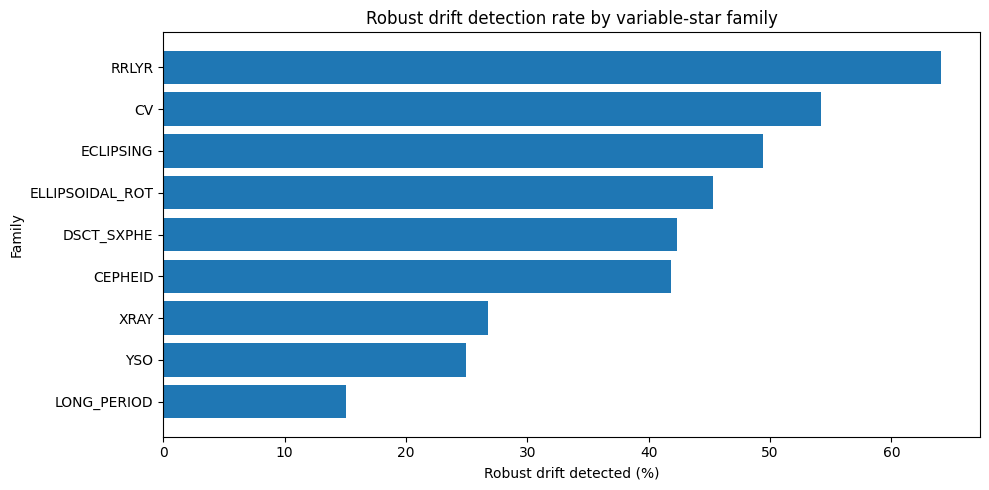

In [8]:
plt.figure(figsize=(10, 5))
plot_df = family_df.sort_values("drift_percent", ascending=True)
plt.barh(plot_df["family"].astype(str), plot_df["drift_percent"])
plt.xlabel("Robust drift detected (%)")
plt.ylabel("Family")
plt.title("Robust drift detection rate by variable-star family")
plt.tight_layout()
plt.show()

## 10. Source/provenance-level summary

The source/provenance comparison is especially important.

Expected behavior:
- SPOC should usually have the lowest robust drift rate because it is a more mature mission pipeline product.
- QLP should generally be low to moderate.
- TESSCut may have a higher drift rate because the pipeline builds simple aperture photometry from cutouts.

In [11]:
def source_summary(df):
    group_col = "provenance"
    if group_col not in df.columns:
        raise ValueError("Column 'provenance' not found.")

    g = df[df.provenance.notna()].groupby(group_col, dropna=False)
    out = g.agg(
        total_count=("robustDriftDetected", "size"),
        drift_count=("robustDriftDetected", lambda x: int(x.fillna(False).astype(bool).sum())),
        median_drift_strength=("robustMedianSegmentDriftStrength", "median"),
        p75_drift_strength=("robustMedianSegmentDriftStrength", lambda x: x.quantile(0.75)),
        p90_drift_strength=("robustMedianSegmentDriftStrength", lambda x: x.quantile(0.90)),
    ).reset_index()
    out["drift_percent"] = 100 * out["drift_count"] / out["total_count"]
    return out.sort_values("drift_percent", ascending=False)

source_df = source_summary(df)
display(source_df.round(3))

,provenance,total_count,drift_count,median_drift_strength,p75_drift_strength,p90_drift_strength,drift_percent
2,TESSCut,5034,3005,10.768,30.735,77.508,59.694
0,QLP,1612,93,1.617,2.636,3.393,5.769
1,SPOC,467,1,0.217,0.616,1.575,0.214


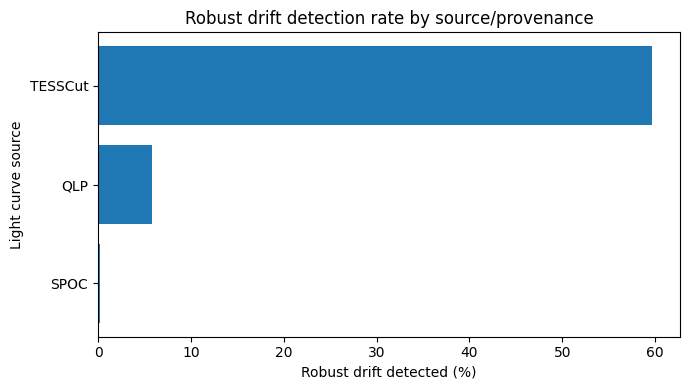

In [12]:
plt.figure(figsize=(7, 4))
plot_df = source_df.sort_values("drift_percent", ascending=True)
plt.barh(plot_df["provenance"].astype(str), plot_df["drift_percent"])
plt.xlabel("Robust drift detected (%)")
plt.ylabel("Light curve source")
plt.title("Robust drift detection rate by source/provenance")
plt.tight_layout()
plt.show()

## 11. Why this should remain a diagnostic, not automatic flattening

The robust drift metric is now reasonable enough to keep, but it should not automatically trigger flattening yet.

Reasons:
1. Some low-frequency or drifting behavior is astrophysical, not instrumental.
2. Family-dependent behavior is expected.
3. TESSCut drift may be photometric/systematic, while long-period variables may contain real slow variability.
4. The core research project is classification from TESS light curves, not building a perfect detrending pipeline.

Therefore:

> `robustDriftDetected` should be stored as metadata and used for analysis, filtering experiments, or future sensitivity tests, not as a mandatory preprocessing rule.

## 12. Recommended conclusion for the project/paper

A concise paper-ready conclusion:

> We investigated automated trend detection before feature extraction. A naive Lomb–Scargle low-frequency test applied to stitched light curves over-identified trends because TESS observations are often separated by large gaps across sectors. Segment-aware LS reduced the conceptual problem but remained sensitive to low-frequency astrophysical structure and edge effects. We therefore implemented a segment-wise robust drift diagnostic based on linear drift relative to MAD scatter. This produced a more interpretable quality metric, especially separating TESSCut from SPOC/QLP behavior. For the current study, we retain these drift metrics as metadata diagnostics rather than automatically flattening all detected cases, avoiding the risk of removing real astrophysical variability.

## 13. Practical next step

Move on to feature extraction and classification.

Recommended next features:
- Lomb–Scargle best period,
- LS peak power,
- false-alarm probability,
- amplitude / percentile range,
- scatter metrics,
- skewness/kurtosis,
- optional robust drift metrics as metadata features or quality covariates.

Flattening can be revisited later as a controlled experiment:

```text
Model A: features from standardized light curves
Model B: features from selectively flattened light curves
Compare classification accuracy and family-level effects
```